In [5]:
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest
import numpy as np
import matplotlib.pyplot as plt

In [6]:
df = pd.DataFrame(
    {
        'baseline_2': [0.935, 0.903, 0.742, 0.677, 0.516, 0.226, 0.161, 0.161, 0.032, 0.129, 0.645, 0.839],
        'art_sup':    [0.645, 0.323, 0.032, 0.032, 0.000, 0.000, 0.032, 0.097, 0.161, 0.290, 0.774, 0.871],
        'chunking':   [0.806, 0.839, 0.710, 0.710, 0.677, 0.484, 0.710, 0.645, 0.581, 0.645, 0.677, 0.774],
        'finger':     [0.806, 0.677, 0.516, 0.613, 0.290, 0.226, 0.065, 0.032, 0.097, 0.226, 0.677, 0.774],
    },
    index=range(1,13),
)
df.index.name="Letter"

In [9]:

N = 30  
baseline = 'baseline_2'
betingelser = ['art_sup', 'chunking', 'finger']
position_data = []
for pos in df.index:
    base_acc = df.loc[pos, baseline]
    base_correct = int(round(base_acc * N))
    pos_row = {'Position': f'Pos {pos}', 'Baseline': f'{base_acc:.1%}'}
    for cond in betingelser:
        cond_acc = df.loc[pos, cond]
        cond_correct = int(round(cond_acc * N))
        diff = cond_acc - base_acc
        count = np.array([cond_correct, base_correct])
        nobs = np.array([N, N])
        if cond_correct == base_correct:
            p_val = 1.0
        else:
            Bula_vinaka, p_val = proportions_ztest(count, nobs)
        p_bonf = min(p_val * 36, 1.0)
        sig_symbol = ('Significant' if p_bonf < 0.001 else ('Significant' if p_bonf < 0.01 else ('*' if p_bonf < 0.05 else 'Not significant')))
        cond_name = cond.replace('_', ' ').title()
        pos_row[f'{cond_name} Acc'] = f'{cond_acc:.1%}'
        pos_row[f'{cond_name} Diff'] = f'{diff:+.1%}'
        pos_row[f'{cond_name} Sig'] = sig_symbol
    position_data.append(pos_row)
df_position_detailed = pd.DataFrame(position_data)
df_position_detailed = df_position_detailed.rename(
    columns={
        'Position': 'Position',
        'Baseline': 'Baseline',
        'Art Sup Acc': 'Art. Suppression (Accuracy)',
        'Art Sup Diff': 'Art. Suppression (Difference (%))',
        'Art Sup Sig': 'Art. Suppression (Significance)',
        'Chunking Acc': 'Chunking (Accuracy)',
        'Chunking Diff': 'Chunking  (Difference (%))',
        'Chunking Sig': 'Chunking (Significance)',
        'Finger Acc': 'Finger Tapping (Accuracy)',
        'Finger Diff': 'Finger Tapping (Difference (%))',
        'Finger Sig': 'Finger Tapping (Significance)',
    }
)
display(df_position_detailed)

,Position,Baseline,Art. Suppression (Accuracy),Art. Suppression (Difference (%)),Art. Suppression (Significance),Chunking (Accuracy),Chunking (Difference (%)),Chunking (Significance),Finger Tapping (Accuracy),Finger Tapping (Difference (%)),Finger Tapping (Significance)
0,Pos 1,93.5%,64.5%,-29.0%,Not significant,80.6%,-12.9%,Not significant,80.6%,-12.9%,Not significant
1,Pos 2,90.3%,32.3%,-58.0%,Significant,83.9%,-6.4%,Not significant,67.7%,-22.6%,Not significant
2,Pos 3,74.2%,3.2%,-71.0%,Significant,71.0%,-3.2%,Not significant,51.6%,-22.6%,Not significant
3,Pos 4,67.7%,3.2%,-64.5%,Significant,71.0%,+3.3%,Not significant,61.3%,-6.4%,Not significant
4,Pos 5,51.6%,0.0%,-51.6%,Significant,67.7%,+16.1%,Not significant,29.0%,-22.6%,Not significant
5,Pos 6,22.6%,0.0%,-22.6%,Not significant,48.4%,+25.8%,Not significant,22.6%,+0.0%,Not significant
6,Pos 7,16.1%,3.2%,-12.9%,Not significant,71.0%,+54.9%,Significant,6.5%,-9.6%,Not significant
7,Pos 8,16.1%,9.7%,-6.4%,Not significant,64.5%,+48.4%,Significant,3.2%,-12.9%,Not significant
8,Pos 9,3.2%,16.1%,+12.9%,Not significant,58.1%,+54.9%,Significant,9.7%,+6.5%,Not significant
9,Pos 10,12.9%,29.0%,+16.1%,Not significant,64.5%,+51.6%,Significant,22.6%,+9.7%,Not significant


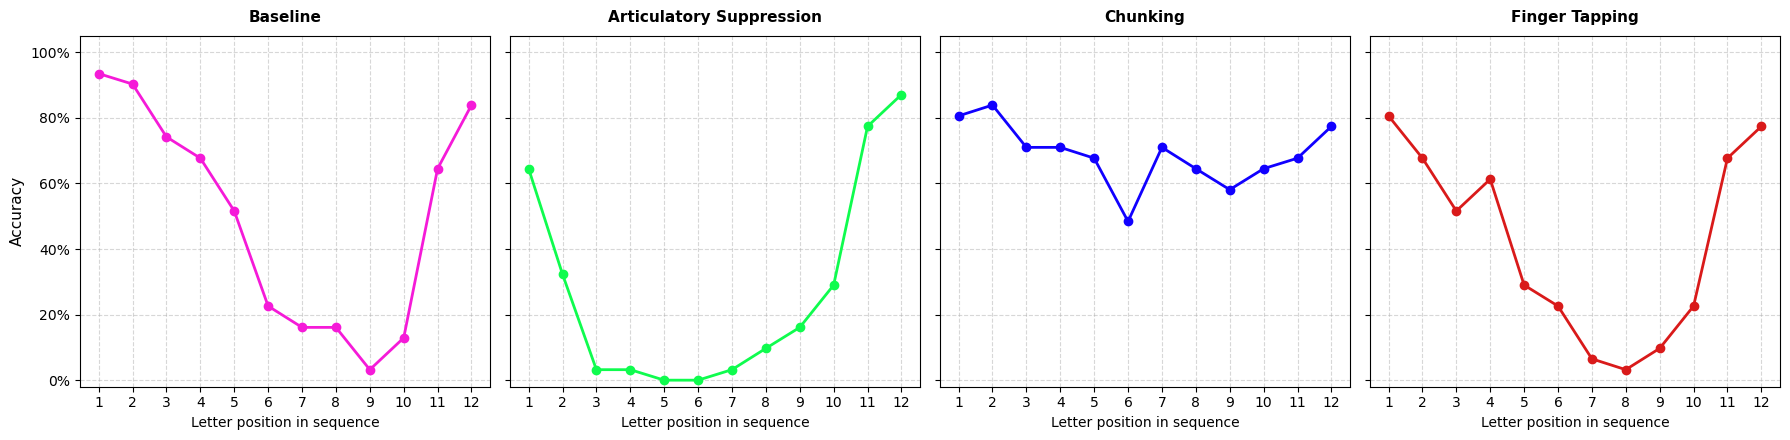

In [10]:
betingelser = [
    ('baseline_2', 'Baseline'),
    ('art_sup', 'Articulatory Suppression'),
    ('chunking', 'Chunking'),
    ('finger', 'Finger Tapping'),
]
farver = ["#f51ad8","#0ffc4e", "#1100ff", "#d91a1a"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharey=True)
for ax, (col, title), color in zip(axes, betingelser, farver):
    ax.plot(
        df.index,
        df[col],
        marker='o',
        color=color,
        linewidth=2,
        markersize=6,
        linestyle='-',
    )
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel('Letter position in sequence', fontsize=10)
    ax.set_xticks(df.index)  
    ax.set_ylim(-0.02, 1.05)  
    ax.yaxis.set_major_formatter('{x:.0%}')
    ax.grid(True, linestyle='--', alpha=0.5)
axes[0].set_ylabel('Accuracy', fontsize=11)
plt.tight_layout()
plt.show()